### Plot 2D ot 3D CAM nstep frequency output ot see if it's noisy

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as mp
import pandas as pd
from scipy.stats import skew

from datetime import datetime as dt
import os
import glob as gb


/glade/derecho/scratch/rneale/archive/f.cam6_4_032.FLTHIST_ne30.cam7_dev.002ts/atm/hist/f.cam6_4_032.FLTHIST_ne30.cam7_dev.002ts_ts_nstep_PRECT.nc
<xarray.Dataset> Size: 329MB
Dimensions:      (lat: 192, lon: 288, time: 1488, nbnd: 2)
Coordinates:
  * lat          (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon          (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.3 357.5 358.8
  * time         (time) float64 12kB 0.02083 0.04167 0.0625 ... 30.96 30.98 31.0
Dimensions without coordinates: nbnd
Data variables:
    time_bounds  (time, nbnd) float64 24kB ...
    PRECT        (time, lat, lon) float32 329MB ...
Attributes: (12/13)
    interp_type:       bilinear
    interp_outputgri:  equally spaced with poles
    Conventions:       CF-1.0
    source:            CAM
    case:              f.cam6_4_032.FLTHIST_ne30.cam7_dev.002ts
    logname:           rneale
    ...                ...
    initial_file:      /glade/campaign/cesm/cesmdata/inputdata/atm/cam/inic/s...
  

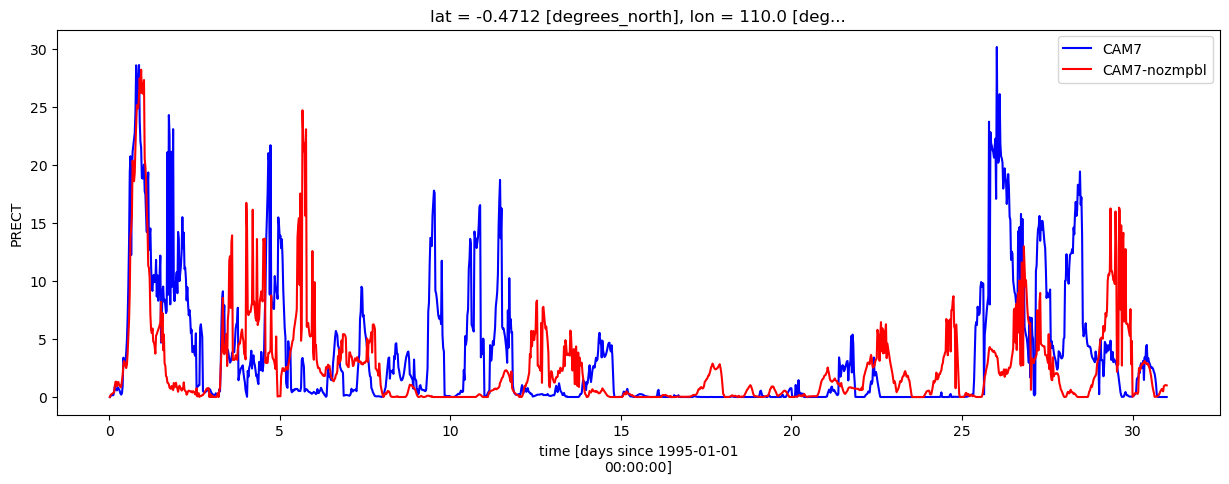

In [2]:
## Read in column data files

dir_root = '/glade/derecho/scratch/rneale/archive/'

run_names = ['f.cam6_4_032.FLTHIST_ne30.cam7_dev.002ts','f.cam6_4_032.FLTHIST_ne30.cam7_dev.003ts']
run_desc = ['CAM7','CAM7-nozmpbl']
pcols = ['b','r']

mp.figure(figsize=(15, 5))

for ir, rname in enumerate(run_names):

    print(file_in := dir_root+rname+'/atm/hist/'+rname+'_ts_nstep_PRECT.nc')
    ds_in = xr.open_dataset(file_in,engine='netcdf4',decode_times=False)
#    ds_in['time'] = xr.decode_cf(ds_in).time
#    ds_in = ds_in.sel(time=slice("1995-01-01", "1995-05-01"),drop=True)

    print(ds_in)
         
#    tt_yr0 = (ds_in.time.dt.year >= tstrt)
#    tt_yr1 = (ds_in.time.dt.year <= tend)
    
#    ds_in = ds_in.where(tt_yr0 & tt_yr1,drop=True)
    da_in = 86400.*1000.*ds_in.PRECT
#    print(da_in.sel(lat=0, lon=110,method='nearest'))
    da_in.sel(lat=0, lon=110,method='nearest').plot(c=pcols[ir], linestyle='-')

mp.legend(run_desc)
